# Ch 10 — 폐암 수술 환자 생존율 예측

원본: `deep_code/01_My_First_Deeplearning.py`

다루는 내용:
1. CSV 로드 (헤더 없음)
2. 17 컬럼 → 1 컬럼 분리
3. Dense 30 → Dense 1 (sigmoid) 모델
4. 책의 MSE 손실 vs 표준 BCE 손실 비교
5. 출력값 직접 디코딩

## 0. 환경 / 시드

In [2]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

I0000 00:00:1778557400.183340 1454588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778557400.184286 1454588 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778557457.547222 1454588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778557457.547840 1454588 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Keras: 3.14.0


## 1. 데이터 로드

책은 `np.loadtxt` 를 사용했지만, pandas로 통일.

In [3]:
DATA = "../../data/ThoraricSurgery.csv"
df = pd.read_csv(DATA, header=None)
print("shape:", df.shape)
df.head()

shape: (470, 18)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,293,1,3.80,2.80,0,0,0,0,0,0,12,0,0,0,1,0,62,0
1,1,2,2.88,2.16,1,0,0,0,1,1,14,0,0,0,1,0,60,0
2,8,2,3.19,2.50,1,0,0,0,1,0,11,0,0,1,1,0,66,1
3,14,2,3.98,3.06,2,0,0,0,1,1,14,0,0,0,1,0,80,1
4,17,2,2.21,1.88,0,0,1,0,0,0,12,0,0,0,1,0,56,0


In [4]:
X = df.iloc[:, 0:17].to_numpy(dtype="float32")
y = df.iloc[:, 17].to_numpy(dtype="float32")
print("X:", X.shape, "y:", y.shape)
print("y 분포:", np.bincount(y.astype(int)))

X: (470, 17) y: (470,)
y 분포: [400  70]


## 2. 모델 — Dense 30 → Dense 1 (sigmoid)

In [5]:
def build_model():
    return Sequential([
        Input(shape=(17,)),
        Dense(30, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

model = build_model()
model.summary()

E0000 00:00:1778557490.311691 1454588 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571 (2.23 KB)

 Trainable params: 571 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

## 3. 학습 — 책 버전 (MSE 손실)

책의 컴파일 그대로. 이진 분류에 MSE를 쓰는 건 흔치 않지만 동작은 함.

In [6]:
keras.utils.set_random_seed(0)
model_mse = build_model()
model_mse.compile(loss="mean_squared_error", optimizer="adam", metrics=["accuracy"])
hist_mse = model_mse.fit(X, y, epochs=30, batch_size=10, verbose=0)
print(f"MSE 모델 train accuracy: {hist_mse.history['accuracy'][-1]:.4f}")

MSE 모델 train accuracy: 0.8511


## 4. 학습 — 표준 버전 (BCE 손실)

`binary_crossentropy` 가 이진 분류의 표준 손실. 같은 모델, 같은 데이터로 비교.

In [7]:
keras.utils.set_random_seed(0)
model_bce = build_model()
model_bce.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
hist_bce = model_bce.fit(X, y, epochs=30, batch_size=10, verbose=0)
print(f"BCE 모델 train accuracy: {hist_bce.history['accuracy'][-1]:.4f}")

BCE 모델 train accuracy: 0.8489


## 5. 학습 곡선 비교

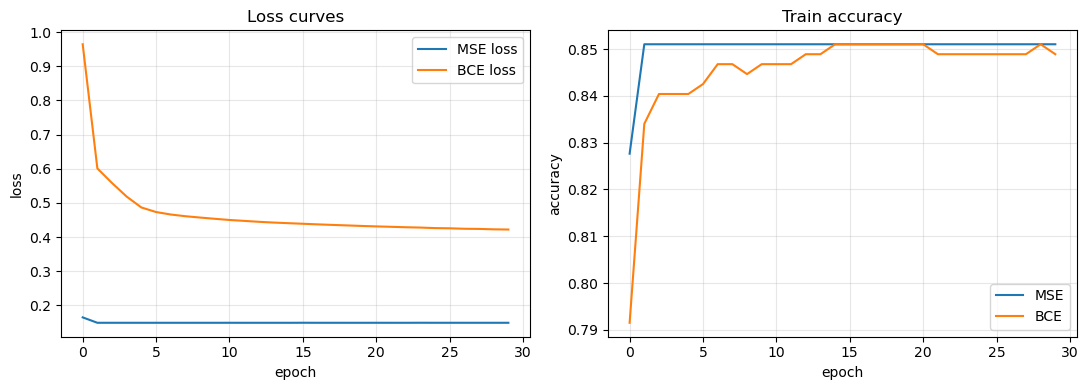

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist_mse.history["loss"], label="MSE loss")
ax[0].plot(hist_bce.history["loss"], label="BCE loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Loss curves")

ax[1].plot(hist_mse.history["accuracy"], label="MSE")
ax[1].plot(hist_bce.history["accuracy"], label="BCE")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[1].set_title("Train accuracy")
plt.tight_layout(); plt.show()

## 6. 출력값 직접 디코딩

`model.predict()` 는 `(N, 1)` 시그모이드 확률을 반환. 0.5 임계값으로 클래스 변환하고 직접 정확도 확인.

In [9]:
probs = model_bce.predict(X[:10], verbose=0)
preds = (probs > 0.5).astype("int32").flatten()
print("확률(처음 10개):", probs.flatten().round(3))
print("예측      :", preds)
print("정답      :", y[:10].astype(int))

확률(처음 10개): [0.03  0.068 0.174 0.113 0.127 0.068 0.175 0.106 0.049 0.058]
예측      : [0 0 0 0 0 0 0 0 0 0]
정답      : [0 0 1 1 0 0 0 1 0 0]


In [10]:
all_preds = (model_bce.predict(X, verbose=0) > 0.5).astype("int32").flatten()
manual_acc = (all_preds == y.astype(int)).mean()
keras_acc = model_bce.evaluate(X, y, verbose=0)[1]
print(f"manual : {manual_acc:.4f}")
print(f"keras  : {keras_acc:.4f}")

manual : 0.8511
keras  : 0.8511


## 마무리 — 체크리스트
- [ ] 470개 데이터로 두 손실 함수 모두 학습 성공
- [ ] BCE 손실이 MSE보다 빠르게 수렴하는지 (loss curve 비교)
- [ ] 시그모이드 출력 → 0.5 임계 → 클래스 변환 직접 해보기
- [ ] 정확도가 양 클래스 분포(`np.bincount(y)`)와 어떤 관계인지 (불균형 데이터)